In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from xgboost import XGBClassifier


In [3]:
train = pd.read_csv('archive/train.csv')
test = pd.read_csv('archive/test.csv')

In [4]:
grade_features = ['GPA', 'TestScore_Math', 'TestScore_Reading', 'TestScore_Science']

# 범주형 변수 인코딩
le_race = LabelEncoder()
le_gender = LabelEncoder()

sample_size = int(len(train) * 0.3)
train = train.sample(n=sample_size, random_state=42, replace=True)
test = test.sample(n=sample_size, random_state=42, replace=True)


race_train_y = le_race.fit_transform(train['Race'])
race_test_y = le_race.fit_transform(test['Race'])
train_x = train[grade_features]

gender_test_y = le_race.fit_transform(test['Gender'])
gender_train_y = le_gender.fit_transform(train['Gender'])   
test_x = test[grade_features]

In [5]:


# cats = X.select_dtypes(exclude=np.number).columns.tolist()
# # Convert to Pandas category
# for col in cats:
#    X[col] = X[col].astype('category')

# X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [6]:
dtrain_reg = xgb.DMatrix(train_x, race_train_y, enable_categorical=True)
dtest_reg = xgb.DMatrix(test_x, race_train_y, enable_categorical=True)
params = {"objective": "reg:squarederror"}

n = 500
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

In [7]:

preds = model.predict(dtest_reg)
rmse = np.sqrt(mean_squared_error(race_train_y, preds,))

print(f"RMSE of the base model: {rmse:.3f}")

RMSE of the base model: 1.770


In [8]:
n=100
params = {"objective": "reg:squarederror", "num_boost_round": 14}
evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   evals=evals
)

[0]	train-rmse:1.76427	validation-rmse:1.76436
[1]	train-rmse:1.76421	validation-rmse:1.76436
[2]	train-rmse:1.76411	validation-rmse:1.76438
[3]	train-rmse:1.76404	validation-rmse:1.76439
[4]	train-rmse:1.76399	validation-rmse:1.76440
[5]	train-rmse:1.76393	validation-rmse:1.76442
[6]	train-rmse:1.76387	validation-rmse:1.76442
[7]	train-rmse:1.76381	validation-rmse:1.76443
[8]	train-rmse:1.76373	validation-rmse:1.76445
[9]	train-rmse:1.76368	validation-rmse:1.76446


RMSE of the base model: 1.764


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

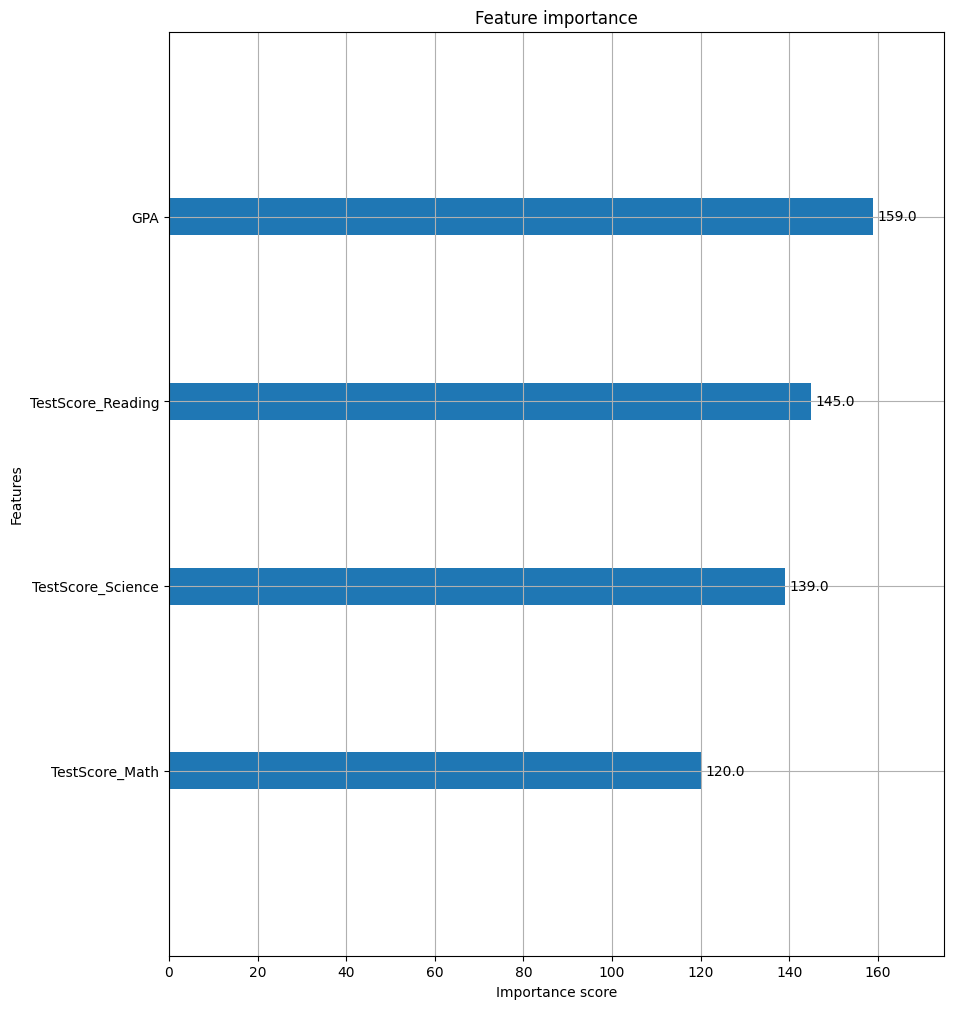

In [9]:
preds = model.predict(dtest_reg)
rmse = np.sqrt(mean_squared_error(race_test_y, preds))
print(f"RMSE of the base model: {rmse:.3f}")

ig, ax = plt.subplots(figsize=(10,12))
xgb.plot_importance(model, ax=ax)

In [10]:
from sklearn.model_selection import GridSearchCV
from hyperopt import fmin, tpe, hp, STATUS_OK
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

X_train_encoded = train_x.copy()
X_test_encoded = test_x.copy()

yc_train = race_train_y.copy()
yc_train[:] = 0
yc_train[race_train_y[:] > np.mean(race_train_y[:])] = 1

yc_test = race_test_y.copy()
yc_test[:] = 0
yc_test[race_test_y[:] > np.mean(race_test_y[:])] = 1


# space = {
#    'max_depth': hp.quniform('max_depth', 2, 8, 1),
#    'learning_rate': hp.loguniform('learning_rate', -5, -2),
#    'subsample': hp.uniform('subsample', 0.5, 1)
#}
#def objective(params):
#    params['max_depth'] = int(params['max_depth'])
#    xgb_model = xgb.XGBRegressor(eval_metric='rmse', **params)
#    xgb_model.fit(X_train_encoded, yc_train.values.ravel())
#    y_pred = xgb_model.predict(X_test_encoded)
#    score = accuracy_score(yc_test, y_pred)
#    return {'loss': -score, 'status': STATUS_OK}

# Perform the optimization
#best_params = fmin(objective, space, algo=tpe.suggest, max_evals=100)
#print("Best set of hyperparameters: ", best_params)

In [13]:

# Encode categorical features
# for col in grade_features:
#     X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
#     X_test_encoded[col] = le.transform(X_test_encoded[col]) # Use the same encoder for test data

param_grid = {"max_depth":    [4, 5, 6],
              "n_estimators": [500, 600, 700],
              "learning_rate": [0.01, 0.015]}
xgb_model = xgb.XGBClassifier()
#xgb_model = xgb.XGBRegressor()

# try out every combination of the above values
search = GridSearchCV(xgb_model, param_grid, cv=2).fit(X_train_encoded, yc_train)
print("The best hyperparameters are ",search.best_params_)


The best hyperparameters are  {'learning_rate': 0.015, 'max_depth': 6, 'n_estimators': 700}


In [14]:
b_param = {'max_depth': 6, 'learning_rate': 0.015, 'n_estimators': 700}
#b_param = {'max_depth': 8, 'learning_rate': 0.078, 'subsample': 0.98}
xgb_model = xgb.XGBClassifier(**b_param)
#xgb_model = xgb.XGBRegressor(**b_param)
xgb_model.fit(X_train_encoded, yc_train)

y_pred = xgb_model.predict(X_test_encoded)
score = accuracy_score(yc_test, y_pred)
print(score)
#rmse = np.sqrt(mean_squared_error(yc_test, y_pred))
#print(f"RMSE of the base model: {rmse:.3f}")

0.508461682037403


https://velog.io/@hyunicecream/GridSearchCV%EB%9E%80-%EC%96%B4%EB%96%BB%EA%B2%8C-%EC%82%AC%EC%9A%A9%ED%95%A0%EA%B9%8C